## SNEEK PEAK

In [1]:
from micrograd.engine import Value

a = Value(-4.0) 
b = Value(2.0)
c = a + b
d = a * b + b**3
c += c + 1 
c += 1 + c + (-a)
d += d * 2 + (b + a).relu()
d += 3 * d + (b - a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10.0
'''
Therefore, we are building an expression graph {Hidden Layer} -> with these two values 'a' and 'b' as 
an input {Input Layer} -> producing an output of 'g' {Output Layer}
So micrograd in the background will create that entire mathematical expression (from c to f) {Therefore acts as that Hidden Layer}
'''
print(f"{g.data:.4f}, the outcome of this forward pass")
'''
Apart from just doing a Forward Pass, i.e. finding g.
We are also going to perform Backpropagation where we find the derivative of g by going backwards 
from output -> hidden -> input by recursively applying chain of rule (from calculus).
So what that allows us to do, is to find the derivative of g w.r.t to all the internal nodes i.e. f, d, c and the input nodes i.e. a & b.
Then we can query the derivative of g w.r.t a
'''
g.backward() 
print(f"{a.grad:.4f}, i.e. the numerical value of dg/da")
print(f"{b.grad:.4f}, i.e. the numerical value of dg/db")

34.5000, the outcome of this forward pass
140.0000, i.e. the numerical value of dg/da
651.0000, i.e. the numerical value of dg/db


## DERIVATIVE SIMPLER FUNCTION

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5

In [4]:
f(3.0)

20.0

In [5]:
xs = np.arange(-5,5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [6]:
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

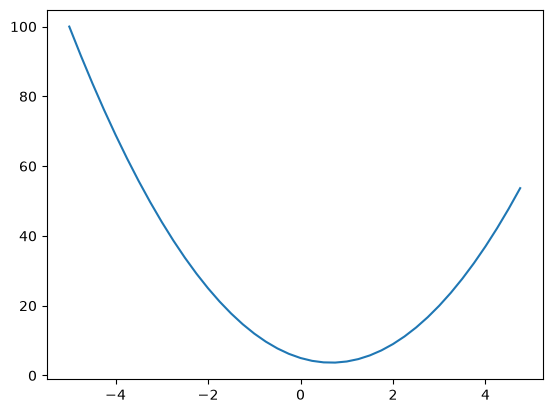

In [7]:
plt.plot(xs, ys)

In [8]:
h = 0.001
x = 3.0
f(x+h)

20.014003000000002

In [9]:
# Next we have to normalise it by adding the value rise of the run i.e. h, to get the value of the slope AKA DERIVATIVE
(f(x+h) - f(x))/h 

14.00300000000243

In [10]:
# Now at some point the slop must be 0, therefore nudging a small value either way from that point, it still remains 0
# In this case, for the function it is at around x = 2/3
h = 0.00000001
x = 2/3
(f(x+h) - f(x))/h

0.0

## Derivative Function with Multiple Inputs

In [11]:
a = 2.0
b = -3.0
c = 10.0

d = a*b + c

In [12]:
h = 0.0001
a += h
d2 = a * b + c
print("d :", d)
print("d2 :", d2)

d : 4.0
d2 : 3.999699999999999


In [13]:
print("slope :", ((d2-d)/h)) # Kinda Partial Derivative

slope : -3.000000000010772


In [14]:
a = 2.0
b = -3.0
c = 10.0
h = 0.0001
d1 = a*b + c

In [15]:
b += h

d2 = a*b + c

print('d1', d1)
print('d2', d2)

print('Slope: ', (d2 - d1)/h)

d1 4.0
d2 4.0002
Slope:  2.0000000000042206


In [16]:
a = 2.0
b = -3.0
c = 10.0
h = 0.0001
d1 = a*b + c

In [17]:
c += h

d2 = a*b + c

print('d1', d1)
print('d2', d2)

print('Slope: ', (d2 - d1)/h)

d1 4.0
d2 4.0001
Slope:  0.9999999999976694


In [18]:
%reset -f

## Value object creation

In [19]:
class Value: # What we saw above 
    def __init__(self, data):
        self.data = data

    def __repr__(self):
        return f"Value(data={self.data})"       
    #__repr__ merely gives that node a readable display name:

 

In [20]:
a = Value(2.0) 
b = Value(-3.0) 

In [21]:
%reset -f

## Visualization of the expression (DATA STRUCTURE)

In [22]:
## Final code after adding method (ADD)
class Value:
    def __init__(self, data, _children=()):
        self.data = data
        self._prev = set(_children) # Children by default stores as tuple, here converted to set 

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other))
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other))
        return out

In [23]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

d = a * b + c
d

Value(data=4.0)

In [24]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [25]:
## We know what childrens were use to create, but we arent aware abouth the operations used with them 

In [26]:
%reset -f

In [27]:
## Final code after adding method (ADD)
class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children) # Children by default stores as tuple, here converted to set 
        self._op = _op 

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [28]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)

d = a * b + c
d

Value(data=4.0)

In [29]:
d._op

'+'

In [30]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

## Graph Visualisation

In [31]:
%reset -f

In [32]:
# Same graph, but we are just adding labels

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children) # Children by default stores as tuple, here converted to set 
        self._op = _op 
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [33]:
import networkx as nx
import matplotlib.pyplot as plt


def trace(root):
    """Collect all nodes and edges in the computation graph."""
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)

            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    nodes, edges = trace(root)

    G = nx.DiGraph()

    # Add nodes
    for node in nodes:
        G.add_node(node)

    # Add edges
    for child, parent in edges:
        G.add_edge(child, parent)

    # Calculate depth so graph flows left → right
    depth = {}

    def assign_depth(node, d=0):
        depth[node] = max(depth.get(node, 0), d)

        for prev in node._prev:
            assign_depth(prev, d + 1)

    assign_depth(root)

    # Group nodes according to depth
    levels = {}

    for node, d in depth.items():
        levels.setdefault(d, []).append(node)

    pos = {}

    max_depth = max(levels)

    for d, level_nodes in levels.items():
        for i, node in enumerate(level_nodes):

            x = max_depth - d

            y = i - (len(level_nodes) - 1) / 2

            pos[node] = (x, y)

    # Labels
    labels = {}

    for node in nodes:
        label = node.label if node.label else "?"
        labels[node] = f"{label}\nvalue = {node.data}"

    plt.figure(figsize=(8, 4))

    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        node_size=3500,
        font_size=10,
        arrows=True,
        arrowsize=20
    )

    # Show operations on edges
    edge_labels = {}

    for child, parent in edges:
        if parent._op:
            edge_labels[(child, parent)] = parent._op

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=11
    )

    plt.title("Computation Graph")
    plt.axis("off")
    plt.show()

In [34]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d= e + c; d.label='d'
f = Value(-2.0, label='f')
L = d*f; L.label='L'
L

Value(data=-8.0)

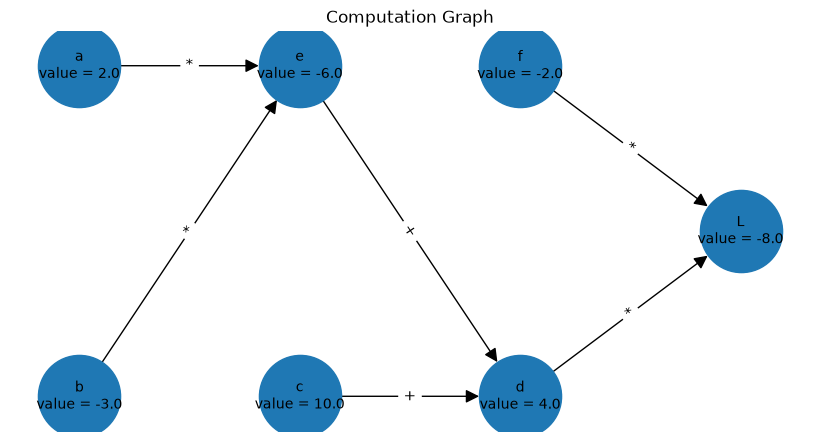

In [35]:
draw_dot(L)

## Backprop - 1

In [36]:
%reset -f

In [37]:
# Therefore during initialization, the gradient values will be set to 0 as we believe that those initial values do not affect the value of the output.

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 
        self._prev = set(_children) # Children by default stores as tuple, here converted to set 
        self._op = _op 
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out

In [38]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d= e + c; d.label='d'
f = Value(-2.0, label='f')
L = d*f; L.label='L'
L

Value(data=-8.0)

In [39]:
import networkx as nx
import matplotlib.pyplot as plt

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)

            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges
    
def draw_dot(root):
    nodes, edges = trace(root)

    G = nx.DiGraph()

    for node in nodes:
        G.add_node(node)

    for child, parent in edges:
        G.add_edge(child, parent)

    depth = {}

    def assign_depth(node, d=0):
        depth[node] = max(depth.get(node, 0), d)

        for prev in node._prev:
            assign_depth(prev, d + 1)

    assign_depth(root)

    levels = {}

    for node, d in depth.items():
        levels.setdefault(d, []).append(node)

    pos = {}

    max_depth = max(levels)

    for d, level_nodes in levels.items():
        for i, node in enumerate(level_nodes):

            x = (max_depth - d) * 1.5
            y = (i - (len(level_nodes) - 1) / 2) * 0.8

            pos[node] = (x, y)

    labels = {}

    for node in nodes:
        label = node.label if node.label else ""
        labels[node] = (
            f"{label}\n"
            f"data={node.data:.3f}\n"
            f"grad={node.grad:.3f}"
        )

    plt.figure(figsize=(9, 4))

    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        node_size=2400,
        font_size=8,
        arrows=True,
        arrowsize=15
    )

    edge_labels = {}

    for child, parent in edges:
        if parent._op:
            edge_labels[(child, parent)] = parent._op

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=9
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

/var/folders/sv/mt61fmhj2qbfcjk052hrdq540000gp/T/ipykernel_53688/3701416860.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


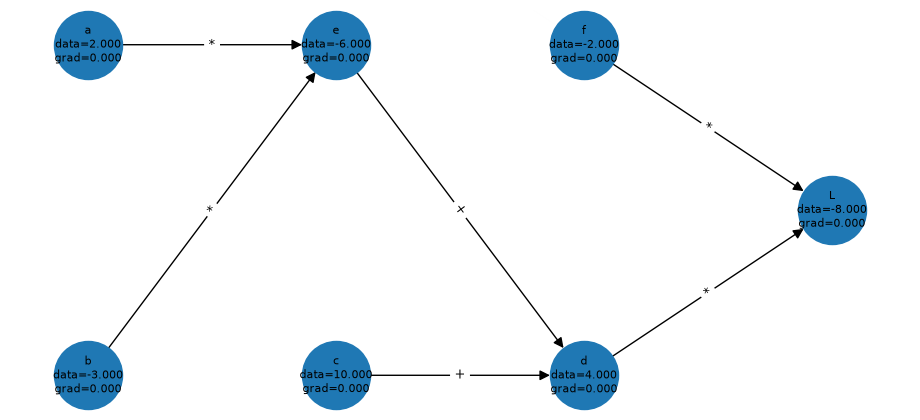

In [40]:
draw_dot(L)

## Now, let's start to fill those grad values

In [41]:
#This is just a staging function to show how the calculation of each of the derivative is taking place
def DILCHASP():

  h = 0.001

  #Here we are basically making them as local variables, to not affect the global variables on top
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L1 = L.data #L is basically a node, so we need its data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L2 = L.data + h

  print((L2-L1)/h)

DILCHASP()

1.000000000000334


/var/folders/sv/mt61fmhj2qbfcjk052hrdq540000gp/T/ipykernel_53688/3701416860.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


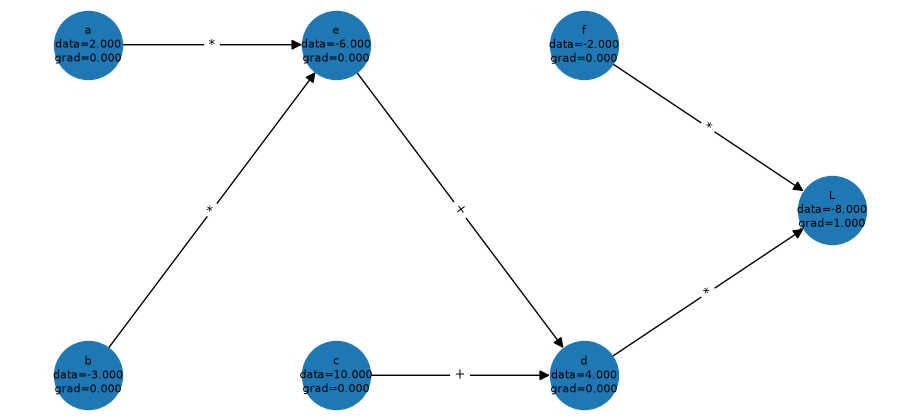

In [42]:
# This was theoritically obvious as well. The derivitive of L wrt L will be one.
L.grad = 1.0 # lets add that value manually
draw_dot(L)

In [43]:
# L wrt to f and d

In [44]:
# D
def lol():

  h = 0.001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L1 = L.data 

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  d.data = d.data + h   # LOOK HERE 
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L2 = L.data

  print((L2-L1)/h)

lol()  # See wrt D its just the vakue of F

-2.000000000000668


In [45]:
# Similar things is gonna happen if done wrt to F, i.e, value of D

In [46]:
# F
def lmao():

  h = 0.00001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L1 = L.data 

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  f = Value(-2.0 + h, label='f')   # HERE
  L = d*f; L.label='L'
  L2 = L.data

  print((L2-L1)/h)

lmao()

4.000000000026205


In [47]:
f.grad = 4.0
d.grad = -2.0

/var/folders/sv/mt61fmhj2qbfcjk052hrdq540000gp/T/ipykernel_53688/3701416860.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


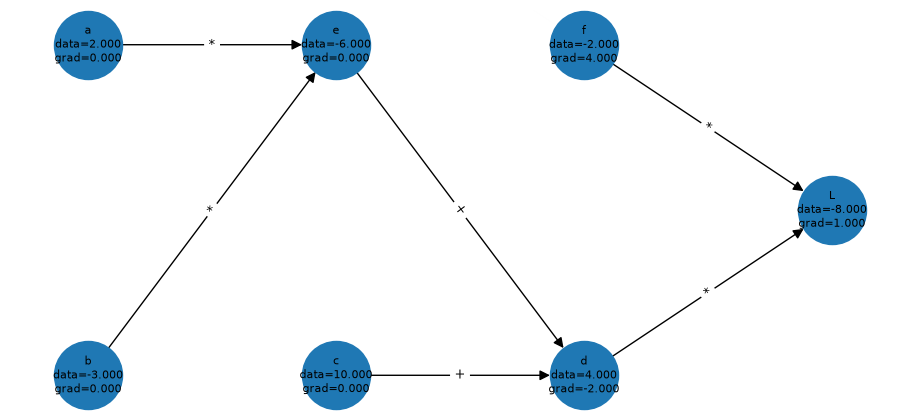

In [48]:
draw_dot(L)

## Manual BackPropogation 2

In [49]:
## Now we'll be calculating the derivatives of the middle nodes

# Starting with `c` & `e`

Given:

$$
d = c + e
$$

From the previous step:

$$
\frac{\partial L}{\partial d} = -2
$$

We want to calculate:

$$
\frac{\partial L}{\partial c}
\quad \text{and} \quad
\frac{\partial L}{\partial e}
$$

## Step 1: Local derivatives

Since:

$$
d = c + e
$$

Differentiate with respect to $c$:

$$
\frac{\partial d}{\partial c}
=
\frac{\partial}{\partial c}(c + e)
$$

Since $e$ is constant with respect to $c$:

$$
\frac{\partial d}{\partial c}
=
1 + 0
=
1
$$

Similarly, with respect to $e$:

$$
\frac{\partial d}{\partial e}
=
\frac{\partial}{\partial e}(c + e)
=
0 + 1
=
1
$$

Therefore:

$$
\frac{\partial d}{\partial c} = 1
$$

and

$$
\frac{\partial d}{\partial e} = 1
$$

## Step 2: Apply the chain rule

For $c$:

$$
\frac{\partial L}{\partial c}
=
\frac{\partial L}{\partial d}
\cdot
\frac{\partial d}{\partial c}
$$

Substituting:

$$
\frac{\partial L}{\partial c}
=
(-2)(1)
=
-2
$$

For $e$:

$$
\frac{\partial L}{\partial e}
=
\frac{\partial L}{\partial d}
\cdot
\frac{\partial d}{\partial e}
$$

Substituting:

$$
\frac{\partial L}{\partial e}
=
(-2)(1)
=
-2
$$

## Final gradients

$$
\boxed{
\frac{\partial L}{\partial c} = -2
}
$$

$$
\boxed{
\frac{\partial L}{\partial e} = -2
}
$$

In [50]:
# NOW WITH c

#This is just a staging function to show how the calculation of each of the derivative is taking place
def lol():

  h = 0.00001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L1 = L.data #L is basically a node, so we need its data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0 + h, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L2 = L.data

  print((L2-L1)/h)

lol()

-1.9999999999242843


In [51]:
# NOW WITH e

#This is just a staging function to show how the calculation of each of the derivative is taking place
def lol():

  h = 0.00001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L1 = L.data #L is basically a node, so we need its data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  e.data += h
  d= e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L2 = L.data

  print((L2-L1)/h)

lol()

-1.9999999999242843


In [52]:
# Therefore, we now add those values manually
c.grad = -2.0
e.grad = -2.0

/var/folders/sv/mt61fmhj2qbfcjk052hrdq540000gp/T/ipykernel_53688/3701416860.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


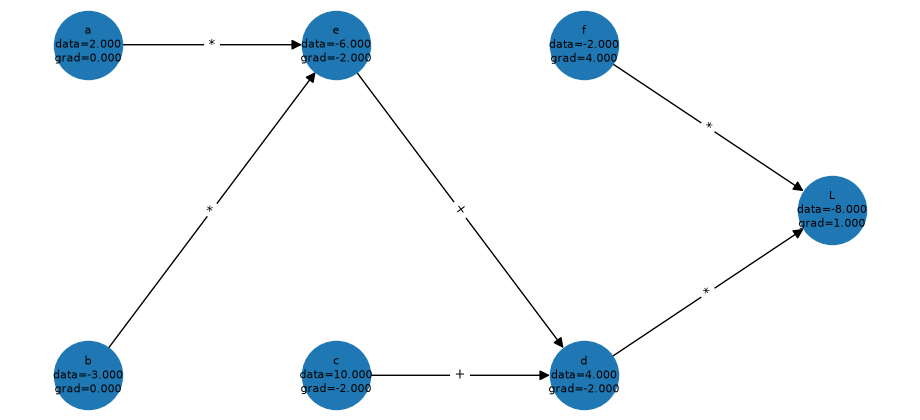

In [53]:
draw_dot(L)

## Continuing with `a` & `b`

Same principle as above, but now we have a multiplication operation.

From the previous step:

$$
\frac{\partial L}{\partial e} = -2
$$

And:

$$
e = a \cdot b
$$

We want to calculate:

$$
\frac{\partial L}{\partial a}
\quad \text{and} \quad
\frac{\partial L}{\partial b}
$$

## Step 1: Local derivatives

Since:

$$
e = a \cdot b
$$

Differentiate with respect to $a$:

$$
\frac{\partial e}{\partial a}
=
\frac{\partial}{\partial a}(a \cdot b)
$$

Since $b$ is constant with respect to $a$:

$$
\frac{\partial e}{\partial a} = b
$$

Similarly, differentiating with respect to $b$:

$$
\frac{\partial e}{\partial b}
=
\frac{\partial}{\partial b}(a \cdot b)
=
a
$$

Therefore:

$$
\frac{\partial e}{\partial a} = b
$$

and

$$
\frac{\partial e}{\partial b} = a
$$

### Mathematical proof for $\frac{\partial e}{\partial a}$

Given:

$$
e = a \cdot b
$$

Using the derivative definition:

$$
\frac{\partial e}{\partial a}
=
\lim_{h \to 0}
\frac{(a+h)b-ab}{h}
$$

Expanding:

$$
=
\lim_{h \to 0}
\frac{ab+hb-ab}{h}
$$

$$
=
\lim_{h \to 0}
\frac{hb}{h}
$$

$$
=
b
$$

Therefore:

$$
\frac{\partial e}{\partial a}=b
$$

Similarly:

$$
\frac{\partial e}{\partial b}=a
$$

## Step 2: Apply the chain rule

For $a$:

$$
\frac{\partial L}{\partial a}
=
\frac{\partial L}{\partial e}
\cdot
\frac{\partial e}{\partial a}
$$

Given:

$$
\frac{\partial L}{\partial e}=-2
$$

and:

$$
b=-3
$$

Therefore:

$$
\frac{\partial L}{\partial a}
=
(-2)(-3)
=
6
$$

For $b$:

$$
\frac{\partial L}{\partial b}
=
\frac{\partial L}{\partial e}
\cdot
\frac{\partial e}{\partial b}
$$

Given:

$$
a=2
$$

Therefore:

$$
\frac{\partial L}{\partial b}
=
(-2)(2)
=
-4
$$

## Final gradients

$$
\boxed{
\frac{\partial L}{\partial a}=6
}
$$

$$
\boxed{
\frac{\partial L}{\partial b}=-4
}
$$

In [54]:
# NOW WITH a

#This is just a staging function to show how the calculation of each of the derivative is taking place
def lol():

  h = 0.00001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L1 = L.data #L is basically a node, so we need its data

  a = Value(2.0 + h, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L2 = L.data

  print((L2-L1)/h)

lol()

6.000000000128124


In [55]:
# NOW WITH b

#This is just a staging function to show how the calculation of each of the derivative is taking place
def lol():

  h = 0.00001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L1 = L.data #L is basically a node, so we need its data

  a = Value(2.0, label='a')
  b = Value(-3.0 + h, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label='e'
  d= e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d*f; L.label='L'
  L2 = L.data

  print((L2-L1)/h)

lol()

-4.000000000026205


In [56]:
#Now, we add those values manually
a.grad = 6.0
b.grad = -4.0

/var/folders/sv/mt61fmhj2qbfcjk052hrdq540000gp/T/ipykernel_53688/3701416860.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


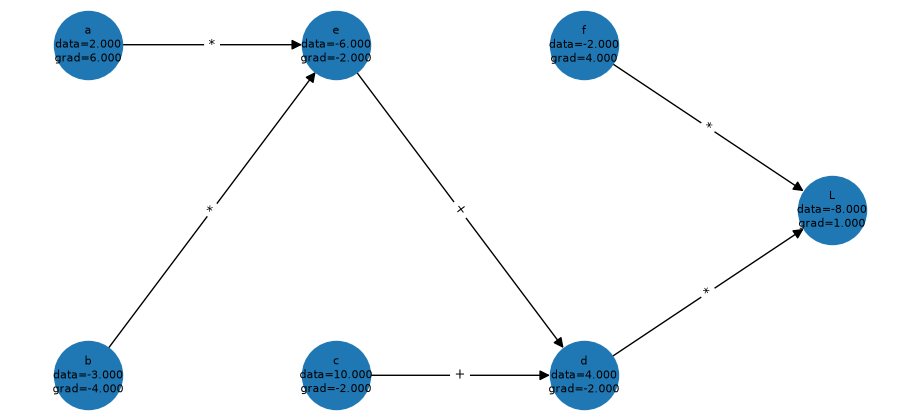

In [57]:
draw_dot(L)

In [58]:
# So if we want L to increase, we should nudge the nodes slightly towards the gradient 

# Nudging the Leaf Nodes Using Their Gradients

Now that we have calculated the gradients, we can actually use them.

The leaf nodes in our graph are:

$$
a,\ b,\ c,\ f
$$

These are the values we directly control.

The final output is:

$$
L = d \cdot f
$$

where:

$$
d = e + c
$$

and:

$$
e = a \cdot b
$$

So the complete computation is:

$$
L = (ab + c)f
$$

---

## What does a gradient tell us?

For any variable $x$:

$$
\frac{\partial L}{\partial x}
$$

tells us how $L$ changes when we slightly change $x$.

For example, if:

$$
\frac{\partial L}{\partial a} = 6
$$

then increasing $a$ slightly will increase $L$.

But if:

$$
\frac{\partial L}{\partial b} = -4
$$

then increasing $b$ would decrease $L$.

So if we want to make $L$ **larger**, we should move each variable in the direction of its gradient.

---

## Gradient ascent step

For each leaf node, we perform:

$$
x_{\text{new}}
=
x_{\text{old}}
+
\eta
\frac{\partial L}{\partial x}
$$

where:

$$
\eta = 0.01
$$

is a small step size, usually called the **learning rate**.

Therefore:

$$
a_{\text{new}}
=
a + 0.01\frac{\partial L}{\partial a}
$$

$$
b_{\text{new}}
=
b + 0.01\frac{\partial L}{\partial b}
$$

$$
c_{\text{new}}
=
c + 0.01\frac{\partial L}{\partial c}
$$

$$
f_{\text{new}}
=
f + 0.01\frac{\partial L}{\partial f}
$$

In code:

```python
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

In [59]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a*b;
d= e + c;
L = d*f;
L

print(L.data) # Therefore the value of L was pushed to a more positive direction

-7.286496


## Backpropagation Neuron - Manual Calculation


In [60]:
%reset -f

In [61]:
# Therefore during initialization, the gradient values will be set to 0 as we believe that those initial values do not affect the value of the output.
import math 
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 
        self._prev = set(_children) # Children by default stores as tuple, here converted to set 
        self._op = _op 
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        return out


    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        return out     

In [62]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label='e'
d = e + c; d.label='d'
f = Value(-2.0, label='f')
L = d*f; L.label='L'
L

Value(data=-8.0)

In [63]:
import networkx as nx
import matplotlib.pyplot as plt

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)

            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges
    
def draw_dot(root):
    nodes, edges = trace(root)

    G = nx.DiGraph()

    for node in nodes:
        G.add_node(node)

    for child, parent in edges:
        G.add_edge(child, parent)

    depth = {}

    def assign_depth(node, d=0):
        depth[node] = max(depth.get(node, 0), d)

        for prev in node._prev:
            assign_depth(prev, d + 1)

    assign_depth(root)

    levels = {}

    for node, d in depth.items():
        levels.setdefault(d, []).append(node)

    pos = {}

    max_depth = max(levels)

    for d, level_nodes in levels.items():
        for i, node in enumerate(level_nodes):

            x = (max_depth - d) * 1.5
            y = (i - (len(level_nodes) - 1) / 2) * 0.8

            pos[node] = (x, y)

    labels = {}

    for node in nodes:
        label = node.label if node.label else ""
        labels[node] = (
            f"{label}\n"
            f"data={node.data:.3f}\n"
            f"grad={node.grad:.3f}"
        )

    plt.figure(figsize=(9, 4))

    nx.draw(
        G,
        pos,
        labels=labels,
        with_labels=True,
        node_size=2400,
        font_size=8,
        arrows=True,
        arrowsize=15
    )

    edge_labels = {}

    for child, parent in edges:
        if parent._op:
            edge_labels[(child, parent)] = parent._op

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=9
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

/var/folders/sv/mt61fmhj2qbfcjk052hrdq540000gp/T/ipykernel_53688/3701416860.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


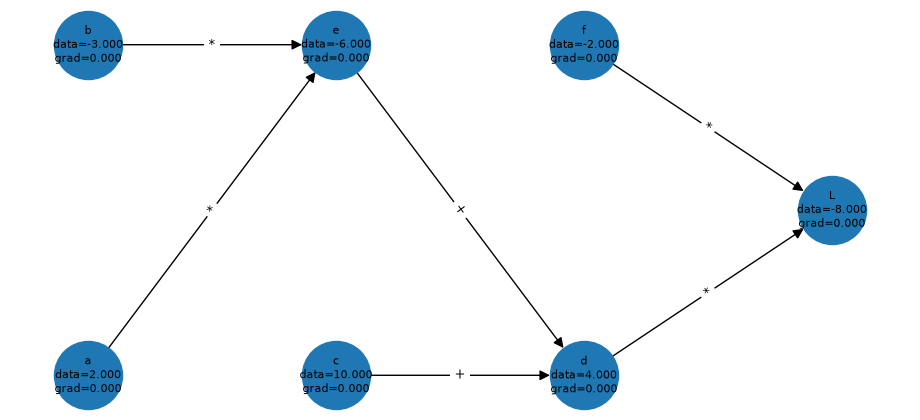

In [64]:
draw_dot(L)

### Implementing the Neuron Mathematical Mode

In [65]:
x1 = Value(0.0, label='x1')
x2 = Value(2.0, label='x2')

w1 = Value(1.0, label='w1')
w2 = Value(-3.0, label='w2')

b = Value(6.8813735870195432, label='b') 

In [66]:
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'

# AND THE... summation
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

# n is the neuron without activation function
n = x1w1x2w2 + b; n.label = 'n'

/var/folders/sv/mt61fmhj2qbfcjk052hrdq540000gp/T/ipykernel_53688/3701416860.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


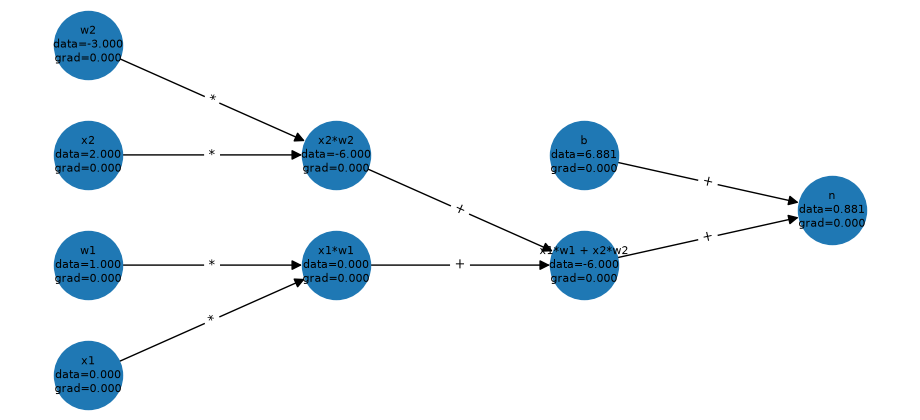

In [67]:
draw_dot(n)

In [68]:
o = n.tanh(); o.label = 'o'

/var/folders/sv/mt61fmhj2qbfcjk052hrdq540000gp/T/ipykernel_53688/3701416860.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


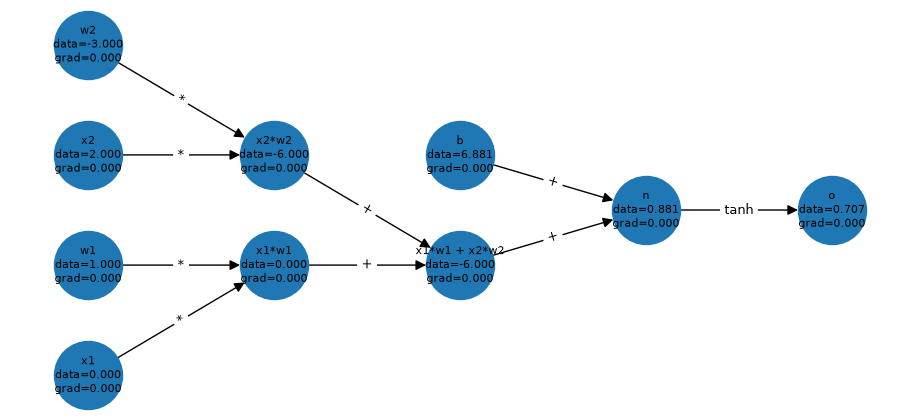

In [69]:
draw_dot(o)

In [70]:
# First we know the derivative of o wrt o will be 1, so
o.grad = 1.0

Now, for do/dn we need to find the derivative through tanh
we know, 0 = tanh(n)
so what will be do/dn
 
We'll refer the derivatives of tanh

We will use the first one in that, i.e. 1 - tan^2 x

In [72]:
n.grad = 0.5

In [73]:
b.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5

In [76]:
x1.grad = 0.5
w1.grad = 0.0
x2.grad = -1.5
w2.grad = 1.0

/var/folders/sv/mt61fmhj2qbfcjk052hrdq540000gp/T/ipykernel_53688/3701416860.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


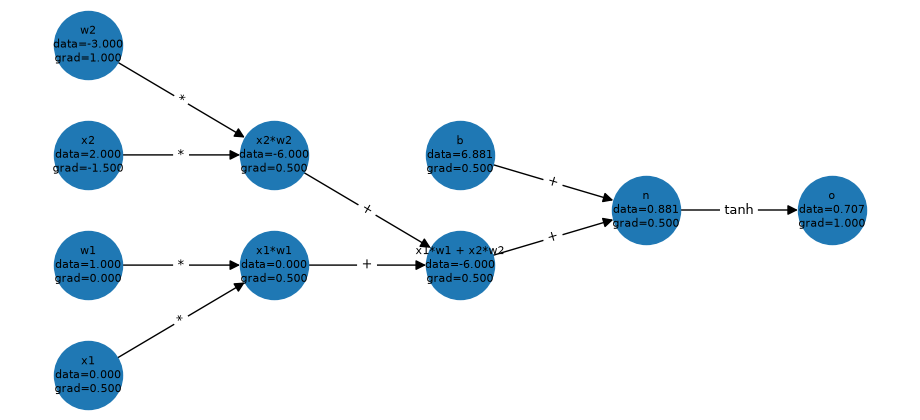

In [77]:
draw_dot(o)